# 2.2 Шаблон задания для СР (Занятие 2)

1) Сначала скачайте файл `variant_*.csv` из генератора (HTML-страница).  
2) Загрузите CSV рядом с ноутбуком (в Colab: через кнопку «📁 Файлы» в левой боковом меню. Затем нажмите на кнопку "📤 Загрузить в сессионное хранилище").  
3) В коде ниже замените имя файла `variant_3.csv` на свой вариант и дополняйте строки с `...`.



In [ ]:
# (Необязательно) Colab: загрузка файла variant_*.csv
# from google.colab import files
# files.upload()


Объём выборки: n = 100

Вариационный ряд:
 [ 58.2,  59.5,  60.5,  61.9,  62.5,  62.7,  63.1,  63.4,  63.8,  64.2,
  64.6,  65.2,  65.4,  66.2,  66.3,  66.4,  67.8,  68.4,  68.8,  69.3,
  70.2,  70.4,  70.4,  71. ,  71.7,  71.7,  72.6,  73. ,  73.2,  73.4,
  73.8,  74. ,  74.1,  74.8,  74.9,  75.1,  75.2,  75.4,  75.5,  75.5,
  75.7,  75.8,  75.9,  76.3,  76.8,  77.3,  77.3,  77.4,  77.6,  77.7,
  78. ,  78.1,  78.1,  78.2,  78.6,  79.1,  79.3,  79.4,  79.5,  79.9,
  80.2,  80.2,  80.4,  80.8,  81.2,  81.4,  81.8,  81.8,  82. ,  82.1,
  82.2,  82.4,  82.4,  82.7,  82.7,  83.2,  83.7,  84.1,  84.5,  84.6,
  85.6,  85.9,  86.2,  86.6,  87. ,  87.1,  87.7,  88.2,  88.6,  89.1,
  89.5,  89.5,  90.4,  92.4,  93.1,  94.6,  94.9,  99.1, 100.5, 101. ]
Первые 5 элементов:  [58.2, 59.5, 60.5, 61.9, 62.5]
Последние 5 элементов:  [ 94.6,  94.9,  99.1, 100.5, 101. ]

Выборочные оценки:
  Среднее:      x̄ =  77.715
  Дисперсия:    s² =  86.31825757575754
  Ст. откл.:    s =  9.290761948072802
  Медиа

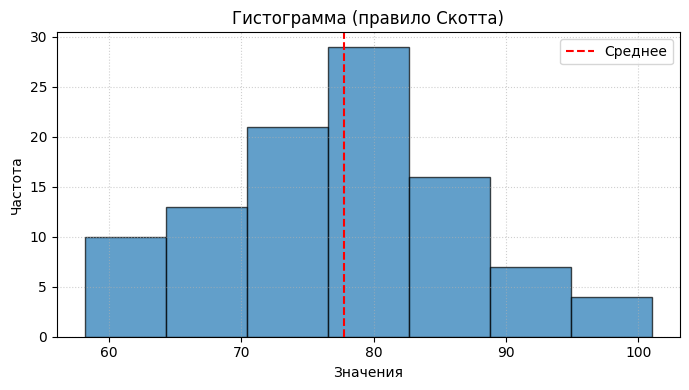

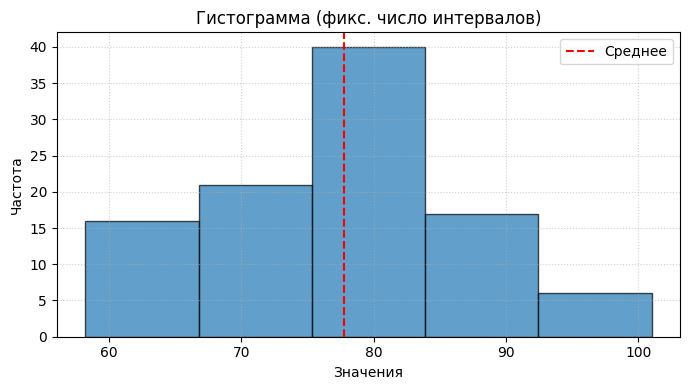

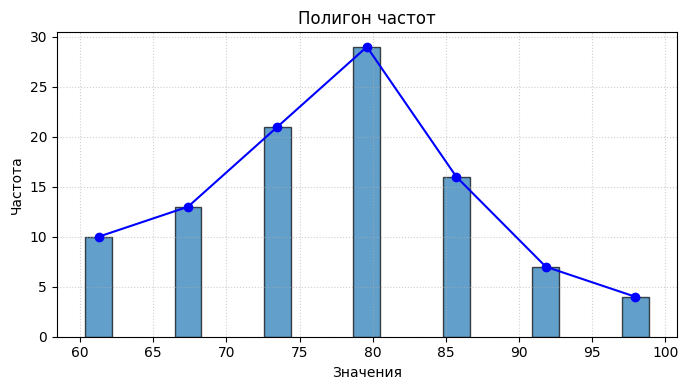

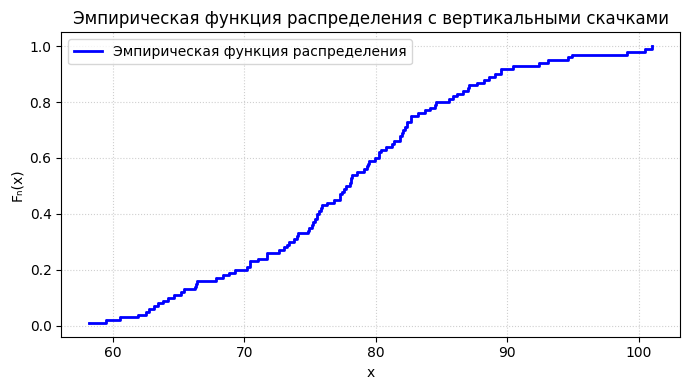

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# ЗАДАНИЕ: Первичная обработка выборки
# -------------------------------------------------
# ШАГ 0: Загрузите свою выборку (замените номер файла на ваш вариант)
data = np.loadtxt('variant_7.csv', delimiter=',')

print(f"Объём выборки: n = {len(data)}")
print()

# -------------------------------------------------
# ШАГ 1: Вариационный ряд
# -------------------------------------------------
# ДОПОЛНИТЕ КОД:
sorted_data = np.sort(data)
print("Вариационный ряд:\n", np.array2string(sorted_data, separator=', '))
print("Первые 5 элементов: ", np.array2string(sorted_data[0:5], separator=', '))
print("Последние 5 элементов: ", np.array2string(sorted_data[-5:], separator=', '))
print()
# Выведите первые 5 и последние 5 значений вариационного ряда

# -------------------------------------------------
# ШАГ 2: Выборочные оценки
# -------------------------------------------------
# ДОПОЛНИТЕ КОД:
x_bar = np.average(data)       # среднее
s2 = np.var(data, ddof=1)          # дисперсия (несмещённая!)
# s2_test = 1/(len(data)-1) * np.sum([(data[i]-x_bar)**2 for i in range(len(data))])
s = np.std(data, ddof=1)           # стандартное отклонение
# s = s2**0.5
median = np.median(data)      # медиана
x_min = np.min(data)       # минимум
x_max = np.max(data)       # максимум

print("Выборочные оценки:")
print(f"  Среднее:      x̄ = ", x_bar)
print(f"  Дисперсия:    s² = ", s2)
print(f"  Ст. откл.:    s = ", s)
print(f"  Медиана:      x̃ = ", median)
print(f"  Размах:       [{x_min:.1f}, {x_max:.1f}]")
print()

# -------------------------------------------------
# ШАГ 3: Правило Скотта и гистограмма
# -------------------------------------------------
# ДОПОЛНИТЕ КОД:
n = len(data)
# s = ...  # уже посчитано в Шаге 2
h = 3.5 * s * n**(-1/3)
k = int(np.ceil((x_max - x_min)/h))  # число интервалов (округлить вверх)

print(f"Правило Скотта:")
print(f"  Ширина интервала: h = {h:.2f}")
print(f"  Число интервалов: k = {k}")
print()

# Постройте ДВЕ гистограммы рядом:
#  а) с числом интервалов по Скотту
#  б) с фиксированным числом интервалов = 5
# Добавьте на каждую вертикальную линию со средним значением
plt.figure(figsize=(7, 4))
plt.hist(sorted_data, bins=k, edgecolor='black', alpha=0.7)
plt.title('Гистограмма (правило Скотта)')
plt.xlabel('Значения')
plt.ylabel('Частота')
plt.grid(True, linestyle=':', alpha=0.6)
plt.axvline(x=x_bar, color='red', linestyle='--', label='Среднее')
plt.legend()
plt.tight_layout()

plt.figure(figsize=(7, 4))
plt.hist(sorted_data, bins=5, edgecolor='black', alpha=0.7)
plt.title('Гистограмма (фикс. число интервалов)')
plt.xlabel('Значения')
plt.ylabel('Частота')
plt.grid(True, linestyle=':', alpha=0.6)
plt.axvline(x=x_bar, color='red', linestyle='--', label='Среднее')
plt.legend()
plt.tight_layout()

# -------------------------------------------------
# ШАГ 4: Полигон частот
# -------------------------------------------------
# ДОПОЛНИТЕ КОД:
# Постройте полигон частот для интервального ряда
# (используйте те же интервалы, что и в гистограмме по Скотту)
plt.figure(figsize=(7, 4))
hist, bin_edges = np.histogram(sorted_data, bins=k)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.hist(sorted_data, bins=k, edgecolor='black', alpha=0.7, rwidth=0.3)
plt.plot(bin_centers, hist, marker='o', linestyle='-', color='b')
plt.title('Полигон частот')
plt.xlabel('Значения')
plt.ylabel('Частота')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# -------------------------------------------------
# ШАГ 5: Эмпирическая функция распределения
# -------------------------------------------------
# ДОПОЛНИТЕ КОД:
# Постройте график ЭФР с пунктирными вертикалями в точках скачков
# и точками на горизонтальных участках
plt.figure(figsize=(7, 4))
f = np.arange(1, n + 1) / n
plt.step(sorted_data, f, where='post', label='Эмпирическая функция распределения', linewidth=2, color='blue')
# f_bottom = np.concatenate(([0], f[:-1]))
# plt.vlines(sorted_data, f_bottom, f, linestyles='dashed', colors='red', label='Скачки', linewidth=1.5)
plt.scatter(sorted_data, f, color='blue', s=1, alpha=0.5) # точки скачков
plt.title('Эмпирическая функция распределения с вертикальными скачками')
plt.xlabel('x')
plt.ylabel('Fₙ(x)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()

# -------------------------------------------------
# ШАГ 6: Сравнение с истинными параметрами
# -------------------------------------------------
# Истинные параметры вашего варианта:
mu_true = 80
sigma2_true = 100

print("Сравнение с истинными параметрами:")
print(f"  Истинное μ = {mu_true}, выборочное x̄ = {x_bar}")
print(f"  Истинное σ² = {sigma2_true}, выборочное s² = {s2}")
print()
print("Вопрос: Почему выборочные оценки отличаются от истинных параметров?")
print("Ответ: В основном из-за конечности и случайности выборки; \nСогласно ЗБЧ, при увеличении объема выборки (n -> inf) оценки будут стремиться к истинным параметрам генеральной совокупности.")
